In [2]:
import pandas as pd

df = pd.read_csv("Airbnb_Open_Data.csv")
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

/tmp/ipykernel_110/1499595385.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [4]:
print(df.describe())

                 id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

In [9]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

In [8]:
df['reviews per month'] = pd.to_numeric(
    df['reviews per month'],
    errors='coerce'
)

df['reviews per month'] = df['reviews per month'].fillna(0)

df['review rate number'] = df['review rate number'].fillna(
    df['review rate number'].median()
)

df['minimum nights'] = df['minimum nights'].fillna(
    df['minimum nights'].median()
)

In [3]:
df.drop(['id', 'host id', 'license', 'house_rules'], axis=1, inplace=True)

In [11]:
df['host_identity_verified'] = df['host_identity_verified'].map({'t':1, 'f':0})

In [12]:
df = df[df['minimum nights'] >= 0]

df = df[(df['availability 365'] >= 0) & (df['availability 365'] <= 365)]

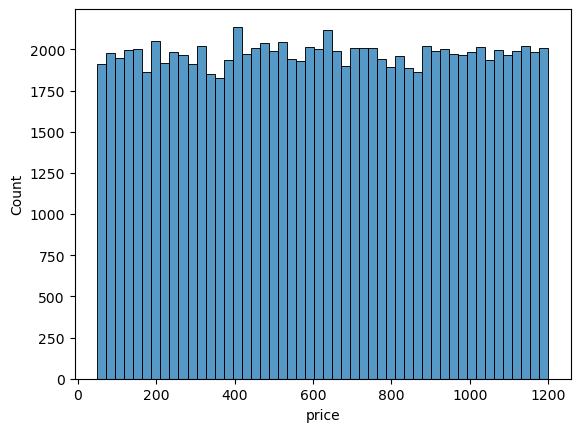

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins=50)
plt.show()

In [14]:
top_price = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)
print(top_price)

neighbourhood group
Queens           629.577313
Bronx            628.157299
Brooklyn         626.744569
Staten Island    624.998926
Manhattan        623.430683
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


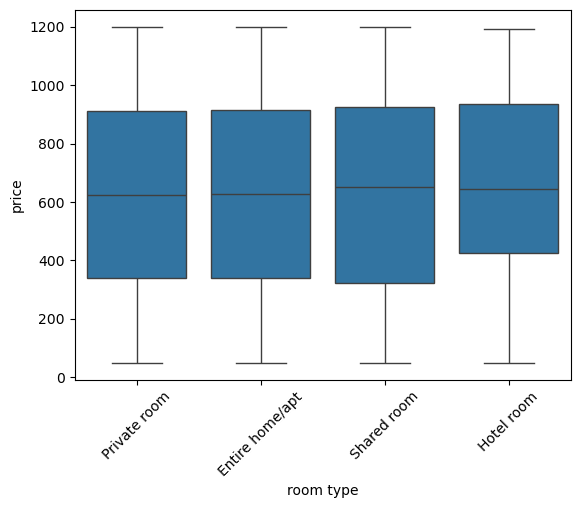

In [15]:
sns.boxplot(x='room type', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

In [17]:
df = pd.get_dummies(df, columns=['room type','neighbourhood group'], drop_first=True)

In [59]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['float64','int64'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print(df.head())

                                               NAME  host_identity_verified  \
0                Clean & quiet apt home by the park                     NaN   
1                             Skylit Midtown Castle                     NaN   
2               THE VILLAGE OF HARLEM....NEW YORK !                     NaN   
3                                               NaN                     NaN   
4  Entire Apt: Spacious Studio/Loft by central park                     NaN   

  host name neighbourhood       lat      long        country country code  \
0  Madaline    Kensington  40.64749 -73.97237  United States           US   
1     Jenna       Midtown  40.75362 -73.98377  United States           US   
2     Elise        Harlem  40.80902 -73.94190  United States           US   
3     Garry  Clinton Hill  40.68514 -73.95976  United States           US   
4    Lyndon   East Harlem  40.79851 -73.94399  United States           US   

  instant_bookable cancellation_policy  ...  availability 365 

In [22]:
df['host_identity_verified'].value_counts(dropna=False)

host_identity_verified
NaN    98925
Name: count, dtype: int64

In [23]:
len(df)

98925

In [24]:
df = df.drop(columns=['host_identity_verified'])

In [26]:
df.isna().sum().sort_values(ascending=False)


last review                          15024
country                                512
host name                              388
calculated host listings count         290
service fee                            262
price                                  235
NAME                                   223
Construction year                      173
number of reviews                      128
country code                           107
instant_bookable                        81
cancellation_policy                     56
neighbourhood                           13
lat                                      8
long                                     8
minimum nights                           0
reviews per month                        0
review rate number                       0
availability 365                         0
room type_Hotel room                     0
room type_Private room                   0
room type_Shared room                    0
neighbourhood group_Brooklyn             0
neighbourho

In [27]:
(df.isna().mean() * 100).sort_values(ascending=False)

last review                          15.187263
country                               0.517564
host name                             0.392216
calculated host listings count        0.293151
service fee                           0.264847
price                                 0.237554
NAME                                  0.225423
Construction year                     0.174880
number of reviews                     0.129391
country code                          0.108163
instant_bookable                      0.081880
cancellation_policy                   0.056609
neighbourhood                         0.013141
lat                                   0.008087
long                                  0.008087
minimum nights                        0.000000
reviews per month                     0.000000
review rate number                    0.000000
availability 365                      0.000000
room type_Hotel room                  0.000000
room type_Private room                0.000000
room type_Sha

In [31]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [32]:
df = df.drop(columns=['host name'])

In [33]:
df['calculated host listings count'] = df['calculated host listings count'].fillna(
    df['calculated host listings count'].median()
)

In [34]:
df['price'].dtype
df['service fee'].dtype

dtype('float64')

In [36]:
df['price'] = df['price'].fillna(df['price'].median())

In [37]:
df.columns

Index(['NAME', 'neighbourhood', 'lat', 'long', 'country', 'country code',
       'instant_bookable', 'cancellation_policy', 'Construction year', 'price',
       'service fee', 'minimum nights', 'number of reviews', 'last review',
       'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365',
       'room type_Hotel room', 'room type_Private room',
       'room type_Shared room', 'neighbourhood group_Brooklyn',
       'neighbourhood group_Manhattan', 'neighbourhood group_Queens',
       'neighbourhood group_Staten Island', 'neighbourhood group_brookln',
       'neighbourhood group_manhatan', 'has_review'],
      dtype='object')

In [38]:
df['Construction year'] = df['Construction year'].fillna(
    df['Construction year'].median()
)

In [39]:
df = df.dropna(subset=['lat','long'])

In [40]:
df['neighbourhood group_Manhattan'] = (
    df['neighbourhood group_Manhattan'] |
    df['neighbourhood group_manhatan']
).astype(int)

df = df.drop(columns=['neighbourhood group_manhatan'])

In [41]:
df['neighbourhood group_Brooklyn'] = (
    df['neighbourhood group_Brooklyn'] |
    df['neighbourhood group_brookln']
).astype(int)

df = df.drop(columns=['neighbourhood group_brookln'])

In [42]:
df.isna().sum().sort_values(ascending=False)

last review                          15023
service fee                            262
NAME                                   223
number of reviews                      128
country code                           107
instant_bookable                        81
cancellation_policy                     56
neighbourhood                           13
country                                  0
lat                                      0
price                                    0
Construction year                        0
long                                     0
minimum nights                           0
reviews per month                        0
review rate number                       0
calculated host listings count           0
availability 365                         0
room type_Hotel room                     0
room type_Private room                   0
room type_Shared room                    0
neighbourhood group_Brooklyn             0
neighbourhood group_Manhattan            0
neighbourho

In [44]:
df = df.drop(columns=['NAME'])

In [45]:
df = df.drop(columns=['last review'])

In [46]:
df['service fee'] = df['service fee'].fillna(
    df['service fee'].median()
)

In [47]:
df['number of reviews'] = df['number of reviews'].fillna(
    df['number of reviews'].median()
)

In [48]:
df['country code'].unique()

array(['US', nan], dtype=object)

In [49]:
df = df.drop(columns=['country code'])

In [50]:
df['cancellation_policy'] = df['cancellation_policy'].fillna(
    df['cancellation_policy'].mode()[0]
)

In [51]:
df['neighbourhood'] = df['neighbourhood'].fillna(
    df['neighbourhood'].mode()[0]
)

In [57]:
df.isna().sum()

neighbourhood                        0
lat                                  0
long                                 0
country                              0
instant_bookable                     0
cancellation_policy                  0
Construction year                    0
price                                0
service fee                          0
minimum nights                       0
number of reviews                    0
reviews per month                    0
review rate number                   0
calculated host listings count       0
availability 365                     0
room type_Hotel room                 0
room type_Private room               0
room type_Shared room                0
neighbourhood group_Brooklyn         0
neighbourhood group_Manhattan        0
neighbourhood group_Queens           0
neighbourhood group_Staten Island    0
has_review                           0
dtype: int64

In [53]:
df['instant_bookable'] = df['instant_bookable'].fillna(
    df['instant_bookable'].mode()[0]
)

/tmp/ipykernel_176/2210312946.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].fillna(


In [54]:
df['instant_bookable'].unique()

array([False,  True])

In [56]:
df['instant_bookable'] = (
    df['instant_bookable']
        .fillna(df['instant_bookable'].mode()[0])
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0, 'yes': 1, 'no': 0})
)

In [58]:
df['price'].describe()

count    98917.000000
mean       625.754703
std        331.341371
min         50.000000
25%        341.000000
50%        626.000000
75%        913.000000
max       1200.000000
Name: price, dtype: float64

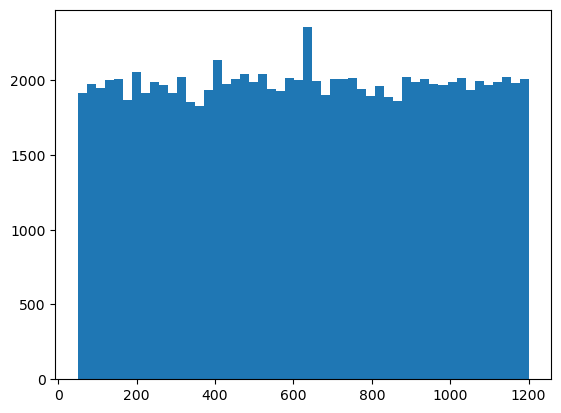

In [60]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=50)
plt.show()

In [61]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                                1.000000
service fee                          0.997842
number of reviews                    0.006117
has_review                           0.005611
neighbourhood group_Queens           0.004503
room type_Hotel room                 0.004417
room type_Shared room                0.003192
neighbourhood group_Brooklyn         0.002456
long                                 0.001446
instant_bookable                     0.000461
calculated host listings count      -0.000212
neighbourhood group_Staten Island   -0.000222
availability 365                    -0.001725
room type_Private room              -0.002188
Construction year                   -0.004539
minimum nights                      -0.004775
neighbourhood group_Manhattan       -0.005989
lat                                 -0.005990
review rate number                  -0.006181
reviews per month                         NaN
Name: price, dtype: float64

<Axes: xlabel='room type_Hotel room', ylabel='price'>

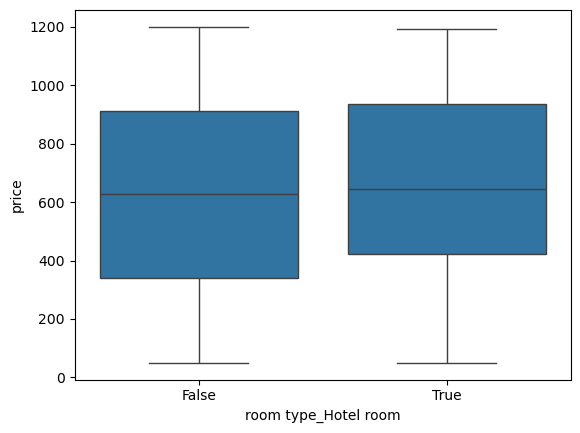

In [62]:
import seaborn as sns
sns.boxplot(x='room type_Hotel room', y='price', data=df)

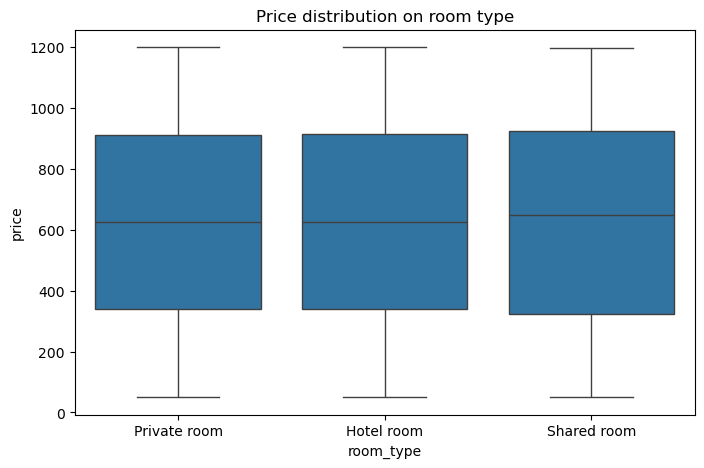

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# coloane one-hot pentru room type
room_cols = ['room type_Hotel room', 'room type_Private room', 'room type_Shared room']

# transformăm din one-hot în categorie pentru vizualizare
df['room_type'] = df[room_cols].idxmax(axis=1).str.replace('room type_', '')

plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price distribution on room type")
plt.show()

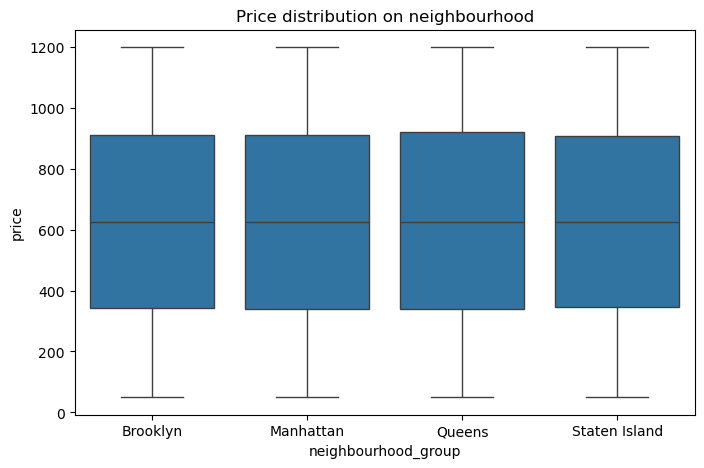

In [69]:
# coloane one-hot
nb_cols = ['neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan', 
           'neighbourhood group_Queens', 'neighbourhood group_Staten Island']

# transformăm în categorie
df['neighbourhood_group'] = df[nb_cols].idxmax(axis=1).str.replace('neighbourhood group_', '')

plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title("Price distribution on neighbourhood")
plt.show()

In [67]:
# NU folosim service fee, pentru că e aproape identic cu prețul
df = df.drop(columns=['service fee'])

In [71]:
y = df['price']
feature_cols = [
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'review rate number',
    'calculated host listings count',
    'availability 365',
    'has_review',
    'room type_Hotel room',
    'room type_Private room',
    'room type_Shared room',
    'neighbourhood group_Brooklyn',
    'neighbourhood group_Manhattan',
    'neighbourhood group_Queens',
    'neighbourhood group_Staten Island'
]

X = df[feature_cols]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 109769.86523464059
R2: -0.0003812606415833919


In [74]:
import pandas as pd

coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

room type_Hotel room                 4.185424e+01
neighbourhood group_Staten Island   -9.352055e+00
neighbourhood group_Queens           5.315632e+00
has_review                           5.139975e+00
room type_Private room              -4.628480e+00
room type_Shared room               -4.237079e+00
neighbourhood group_Manhattan       -1.990611e+00
review rate number                  -1.808084e+00
neighbourhood group_Brooklyn         1.378807e+00
minimum nights                      -6.141860e-02
number of reviews                    3.493672e-02
calculated host listings count       1.528734e-02
availability 365                    -3.630202e-03
reviews per month                   -6.085410e-15
dtype: float64
